In [1]:
import pandas as pd
import numpy as np
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from ndlinear import NdLinear
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
# Load data
# Source: https://www.kaggle.com/datasets/eoinamoore/historical-nba-data-and-player-box-scores?resource=download&select=TeamStatistics.csv
team_stats = pd.read_csv("data/TeamStatistics.csv")


In [3]:
# Clean data
cols_to_ignore = ["gameDate", "coachId", "gameId", "teamId", "teamCity", "teamName", "opponentTeamCity", "opponentTeamName", "opponentTeamId", "opponentScore", "teamScore"]
team_stats = team_stats.drop(columns=cols_to_ignore)
team_stats = team_stats.fillna(value=0.0)

x = team_stats.drop(columns=["win"]) # input values
y =  team_stats["win"] # output
feature_names = x.columns



In [4]:
# Scale features
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [5]:
# Split into training/test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
x = pd.DataFrame(x, columns=feature_names)

In [6]:
# Converting input and output to tensors
x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)


In [7]:
# Define prediction model using PyTorch
class NBAGamePredictorPyTorch(nn.Module):
    def __init__(self, input_size):
        super(NBAGamePredictorPyTorch, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

pytorch_model = NBAGamePredictorPyTorch(input_size=x_train.shape[1])

In [8]:
# Define prediction model using NdLinear
class NBAGamePredictorNdLinear(nn.Module):
    def __init__(self, input_size):
        super(NBAGamePredictorNdLinear, self).__init__()
        self.model = nn.Sequential(
            NdLinear((input_size,), (32,)),
            nn.ReLU(),
            NdLinear((32,), (16,)),
            nn.ReLU(),
            NdLinear((16,), (1,)),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

ndlinear_model = NBAGamePredictorNdLinear(input_size=x_train.shape[1])

In [9]:
# Function for training a model given num epochs

def train_model(model, epochs):
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    start_time = time.time()
    loss_history = []
    acc_history = []

    for epoch in range(0, epochs):
        model.train()
        output = model(x_train)
        loss = criterion(output, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc = ((output > 0.5) == y_train).float().mean().item()

        # Store for plotting if I need it
        loss_history.append(loss.item())
        acc_history.append(acc)
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Accuracy: {acc}")


    end_time = time.time()
    train_time = end_time - start_time
    return train_time

In [10]:
# Evaluate model function

def evaluate_model(model, x_test, y_test):
    model.eval()
    with torch.no_grad():
        preds = model(x_test)
        binary_preds = (preds > 0.5).float()

        # Convert to numpy
        y_true = y_test.cpu().numpy()
        y_pred = binary_preds.cpu().numpy()

        # Compute metrics
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        params = sum(p.numel() for p in model.parameters())

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "param_count": params
    }



In [11]:
# Function to train and evaluate model

def run_train_and_eval(model_class, input_size, epochs=40):
    metrics_list = []

    model = model_class(input_size)
    train_time = train_model(model, epochs)
    result = evaluate_model(model, x_test, y_test)
    result["Training Time (s)"] = train_time
    metrics_list.append(result)

    return pd.DataFrame(metrics_list).mean(numeric_only=True).to_dict()


In [12]:
# Comparing nn.Linear vs NdLinear

linear_avg = run_train_and_eval(NBAGamePredictorPyTorch, x_train.shape[1])
ndlinear_avg = run_train_and_eval(NBAGamePredictorNdLinear, x_train.shape[1])

comparison_df = pd.DataFrame([linear_avg, ndlinear_avg], index=["nn.Linear", "NdLinear"])

# Display comparison
print("\n Model Benchmark Comparison (nn.Linear vs NdLinear):")
print(comparison_df)

print("\n Summary:")
better_model = "NdLinear" if ndlinear_avg["f1"] > linear_avg["f1"] else "nn.Linear"
print(f"-  F1 Score Winner: {better_model}")
print(f"- Params: {comparison_df.loc['nn.Linear', 'param_count']} (nn.Linear) vs {comparison_df.loc['NdLinear', 'param_count']} (NdLinear)")


Epoch 0: Accuracy: 0.49201640486717224
Epoch 10: Accuracy: 0.6197105646133423
Epoch 20: Accuracy: 0.7933747172355652
Epoch 30: Accuracy: 0.8289289474487305
Epoch 0: Accuracy: 0.4992647171020508
Epoch 10: Accuracy: 0.5509862899780273
Epoch 20: Accuracy: 0.6737728714942932
Epoch 30: Accuracy: 0.7798438668251038

 Model Benchmark Comparison (nn.Linear vs NdLinear):
           accuracy  precision    recall        f1  param_count  \
nn.Linear  0.848282   0.843084  0.852731  0.847880       1729.0   
NdLinear   0.814556   0.798500  0.837288  0.817434       1729.0   

           Training Time (s)  
nn.Linear           0.645304  
NdLinear            0.666809  

 Summary:
-  F1 Score Winner: nn.Linear
- Params: 1729.0 (nn.Linear) vs 1729.0 (NdLinear)


In [13]:
# Function to run training and keep track of metrics

def train_and_track(model_class, input_size, max_epochs=100):
    model = model_class(input_size)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(max_epochs):
        # Training step
        model.train()
        output = model(x_train)
        loss = criterion(output, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Training metrics
        train_pred = (output > 0.5).float()
        train_acc = (train_pred == y_train).float().mean().item()
        train_losses.append(loss.item())
        train_accuracies.append(train_acc)

        # Evaluation on test set
        model.eval()
        with torch.no_grad():
            test_output = model(x_test)
            test_loss = criterion(test_output, y_test).item()
            test_pred = (test_output > 0.5).float()
            test_acc = (test_pred == y_test).float().mean().item()

            test_losses.append(test_loss)
            test_accuracies.append(test_acc)

    return {
        "train_loss": train_losses,
        "test_loss": test_losses,
        "train_acc": train_accuracies,
        "test_acc": test_accuracies
    }

# Run tracking
nn_stats = train_and_track(NBAGamePredictorPyTorch, x_train.shape[1], max_epochs=100)
nd_stats = train_and_track(NBAGamePredictorNdLinear, x_train.shape[1], max_epochs=100)



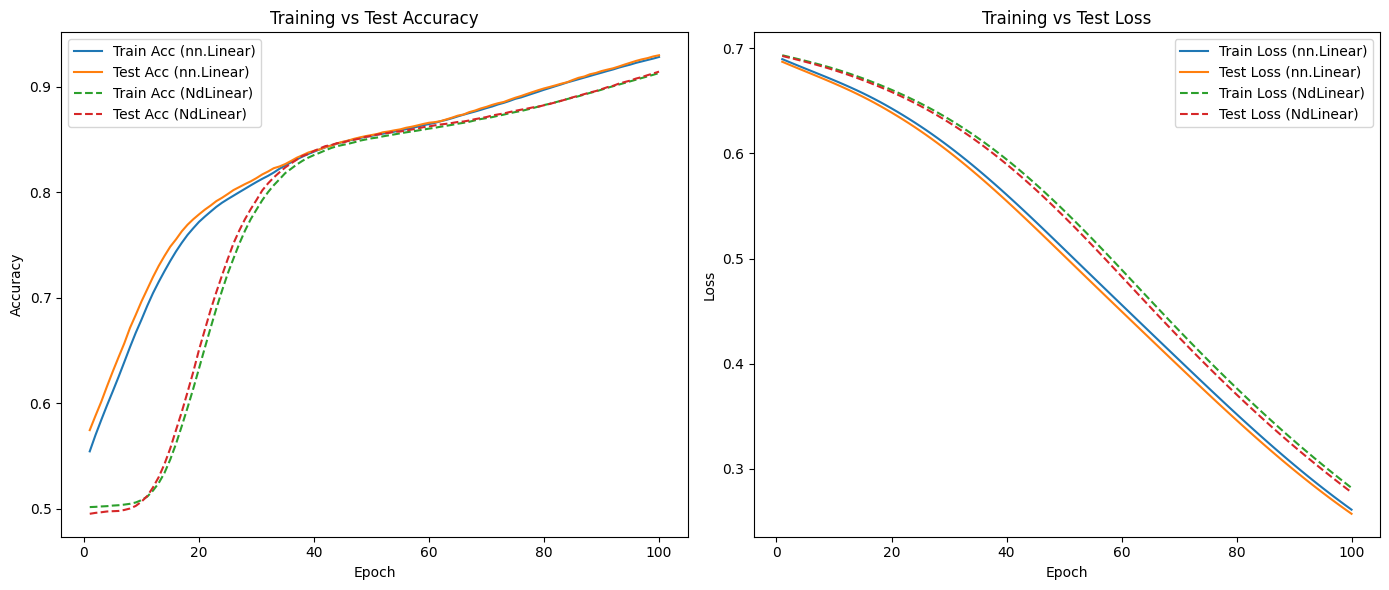

In [14]:
# Plotting
epochs = list(range(1, 101))
plt.figure(figsize=(14, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, nn_stats["train_acc"], label="Train Acc (nn.Linear)")
plt.plot(epochs, nn_stats["test_acc"], label="Test Acc (nn.Linear)")
plt.plot(epochs, nd_stats["train_acc"], label="Train Acc (NdLinear)", linestyle='--')
plt.plot(epochs, nd_stats["test_acc"], label="Test Acc (NdLinear)", linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, nn_stats["train_loss"], label="Train Loss (nn.Linear)")
plt.plot(epochs, nn_stats["test_loss"], label="Test Loss (nn.Linear)")
plt.plot(epochs, nd_stats["train_loss"], label="Train Loss (NdLinear)", linestyle='--')
plt.plot(epochs, nd_stats["test_loss"], label="Test Loss (NdLinear)", linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [15]:
import random

def predict_match_from_recent_games(home_team_name, away_team_name, n_games, team_stats_df, model, scaler):
    # Get team stats from last n games
    team1_games = team_stats_df[team_stats_df["teamName"] == home_team_name].sort_values("gameDate", ascending=False).head(n_games)
    team2_games = team_stats_df[team_stats_df["teamName"] == away_team_name].sort_values("gameDate", ascending=False).head(n_games)

    if len(team1_games) < n_games or len(team2_games) < n_games:
        raise ValueError("Not enough recent games for one or both teams.")

    # Average recent performance
    cols_to_ignore.append("win")
    team1_avg = team1_games.drop(columns=cols_to_ignore).mean()
    team2_avg = team2_games.drop(columns=cols_to_ignore).mean()

    matchup_row = {
        "home": random.choice([0,1]),
    }

    # Home team stats
    for col in team1_avg.index:
        matchup_row[col] = team1_avg[col]

    # Away team stats
    for col in team2_avg.index:
        matchup_row[f"opponent{col[0].upper() + col[1:]}"] = team2_avg[col]

    matchup_df = pd.DataFrame([matchup_row])
    matchup_df = matchup_df.reindex(columns=feature_names, fill_value=0)

    # Scale features
    matchup_scaled = scaler.transform(matchup_df)
    input_tensor = torch.tensor(matchup_scaled, dtype=torch.float32)

    # Predict
    model.eval()
    with torch.no_grad():
        pred = model(input_tensor).item()
    if pred >= 0.5:
        winner = home_team_name
    else:
        winner = away_team_name
        pred = 1- pred
    return winner, pred


In [16]:
winner, prob = predict_match_from_recent_games(
    home_team_name="Timberwolves",
    away_team_name="Lakers",
    n_games=5,
    team_stats_df=pd.read_csv("data/TeamStatistics.csv"),
    model=ndlinear_model,
    scaler=scaler
)

print(f"Predicted Winner: {winner} (Confidence: {prob:.2f})")


Predicted Winner: Timberwolves (Confidence: 0.50)


In [17]:
def simulate_series(home_team, away_team, n_games, team_stats_df, model, scaler):
    wins_team1 = 0
    wins_team2 = 0

    for _ in range(7):  # Best of 7 series
        winner, _ = predict_match_from_recent_games(
            home_team_name=home_team,
            away_team_name=away_team,
            n_games=n_games,
            team_stats_df=team_stats_df,
            model=model,
            scaler=scaler
        )

        if winner == home_team:
            wins_team1 += 1
        else:
            wins_team2 += 1

        if wins_team1 == 4:
            return home_team
        if wins_team2 == 4:
            return away_team

    # If somehow no one gets to 4 wins in 7 games, return the one with more wins
    return home_team if wins_team1 > wins_team2 else away_team


In [18]:
def simulate_playoffs(bracket, n_games, team_stats_df, model, scaler):
    round_num = 1
    while True:
        print(f"\nRound {round_num}:")
        next_round = []

        for match in bracket:
            if len(match) != 2:
                continue
            team1, team2 = match
            winner = simulate_series(team1, team2, n_games, team_stats_df, model, scaler)
            print(f"-  {team1} vs {team2} -> Winner: {winner}")
            next_round.append(winner)

        if len(next_round) == 1:
            champion = next_round[0]
            break

        bracket = [[next_round[i], next_round[i + 1]] for i in range(0, len(next_round), 2)]
        round_num += 1

    print(f"\n Champion: {champion}")
    return champion



initial_bracket = [
    ["Thunder", "Grizzlies"],
    ["Nuggets", "Clippers"],
    ["Lakers", "Timberwolves"],
    ["Rockets", "Warriors"],
    ["Cavaliers", "Heat"],
    ["Pacers", "Bucks"],
    ["Knicks", "Pistons"],
    ["Celtics", "Magic"]
]

nd_linear_champion = simulate_playoffs(
    bracket=initial_bracket,
    n_games=82, # Gonna be whole season-ish
    team_stats_df=pd.read_csv("data/TeamStatistics.csv"),
    model=ndlinear_model,
    scaler=scaler
)

pytorch_champion = simulate_playoffs(
    bracket=initial_bracket,
    n_games=82, # Gonna be whole season-ish
    team_stats_df=pd.read_csv("data/TeamStatistics.csv"),
    model=pytorch_model,
    scaler=scaler
)


Round 1:
-  Thunder vs Grizzlies -> Winner: Thunder
-  Nuggets vs Clippers -> Winner: Nuggets
-  Lakers vs Timberwolves -> Winner: Lakers
-  Rockets vs Warriors -> Winner: Rockets
-  Cavaliers vs Heat -> Winner: Cavaliers
-  Pacers vs Bucks -> Winner: Pacers
-  Knicks vs Pistons -> Winner: Knicks
-  Celtics vs Magic -> Winner: Celtics

Round 2:
-  Thunder vs Nuggets -> Winner: Thunder
-  Lakers vs Rockets -> Winner: Lakers
-  Cavaliers vs Pacers -> Winner: Cavaliers
-  Knicks vs Celtics -> Winner: Knicks

Round 3:
-  Thunder vs Lakers -> Winner: Thunder
-  Cavaliers vs Knicks -> Winner: Cavaliers

Round 4:
-  Thunder vs Cavaliers -> Winner: Thunder

 Champion: Thunder

Round 1:
-  Thunder vs Grizzlies -> Winner: Thunder
-  Nuggets vs Clippers -> Winner: Nuggets
-  Lakers vs Timberwolves -> Winner: Lakers
-  Rockets vs Warriors -> Winner: Rockets
-  Cavaliers vs Heat -> Winner: Cavaliers
-  Pacers vs Bucks -> Winner: Pacers
-  Knicks vs Pistons -> Winner: Knicks
-  Celtics vs Magic -> 